# 📊 EDA & Predictive Analysis: Smartphone Usage, Sleep Quality & Stress

This project explores the relationship between smartphone usage, sleep patterns, and stress levels using exploratory data analysis techniques. The objective is to uncover patterns and correlations that explain how digital habits and lifestyle factors influence mental well-being.

The analysis includes univariate, bivariate, and correlation analysis to evaluate the impact of screen time, phone usage before sleep, caffeine intake, and physical activity on sleep quality and stress levels.

To enhance the analysis, a machine learning model is applied to identify the most significant predictors of stress levels, providing deeper insight into the factors driving mental fatigue.

The insights derived from this study are further translated into an interactive Power BI dashboard for better visualization and decision-making.

In [40]:
## Import required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [41]:
## Load Dataset 
df = pd.read_csv('sleep_mobile_stress_dataset_15000.csv')


In [42]:
# Initial Inspection

df.head()

,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99


In [43]:
df.tail()

,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
14995,14996,39,Male,Manager,8.05,45,8.91,4.33,10.00,1,40,259,10.00
14996,14997,22,Female,Student,6.44,80,6.00,5.22,10.00,2,41,231,7.54
14997,14998,51,Female,Software Engineer,7.01,78,7.27,5.37,8.66,4,93,288,7.78
14998,14999,56,Female,Software Engineer,7.89,6,5.70,5.71,9.56,1,91,47,9.98
14999,15000,20,Female,Freelancer,6.05,93,4.74,5.04,9.33,0,117,64,9.26


In [44]:
df.shape

(15000, 13)

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   user_id                           15000 non-null  int64  
 1   age                               15000 non-null  int64  
 2   gender                            15000 non-null  object 
 3   occupation                        15000 non-null  object 
 4   daily_screen_time_hours           15000 non-null  float64
 5   phone_usage_before_sleep_minutes  15000 non-null  int64  
 6   sleep_duration_hours              15000 non-null  float64
 7   sleep_quality_score               15000 non-null  float64
 8   stress_level                      15000 non-null  float64
 9   caffeine_intake_cups              15000 non-null  int64  
 10  physical_activity_minutes         15000 non-null  int64  
 11  notifications_received_per_day    15000 non-null  int64  
 12  ment

In [46]:
df.describe()

,user_id,age,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000
mean,7500.500000,38.488467,5.501528,59.708933,6.509683,6.246362,6.980247,1.99880,59.157133,160.890467,6.873009
std,4330.271354,12.007970,2.600085,34.641858,1.452689,1.713644,2.749382,1.41459,34.525705,80.856902,2.730482
min,1.000000,18.000000,1.000000,0.000000,4.000000,1.000000,1.000000,0.00000,0.000000,20.000000,1.000000
25%,3750.750000,28.000000,3.260000,29.000000,5.260000,5.000000,4.750000,1.00000,29.000000,92.000000,4.700000
50%,7500.500000,38.000000,5.490000,60.000000,6.490000,6.250000,7.380000,2.00000,59.000000,162.000000,7.380000
75%,11250.250000,49.000000,7.760000,90.000000,7.790000,7.500000,10.000000,3.00000,89.000000,231.000000,9.450000
max,15000.000000,59.000000,10.000000,119.000000,9.000000,10.000000,10.000000,4.00000,119.000000,299.000000,10.000000


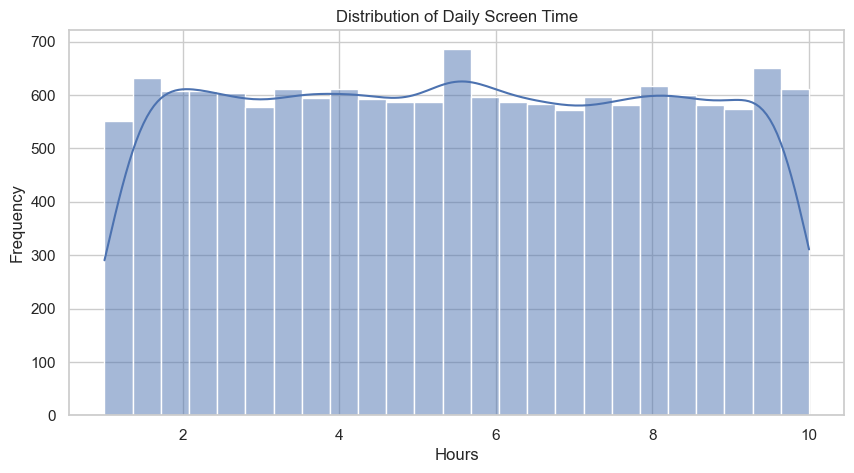

In [47]:
plt.figure(figsize=(10,5))
sns.histplot(df['daily_screen_time_hours'], kde=True)
plt.title('Distribution of Daily Screen Time')
plt.xlabel('Hours')
plt.ylabel('Frequency')
plt.show()

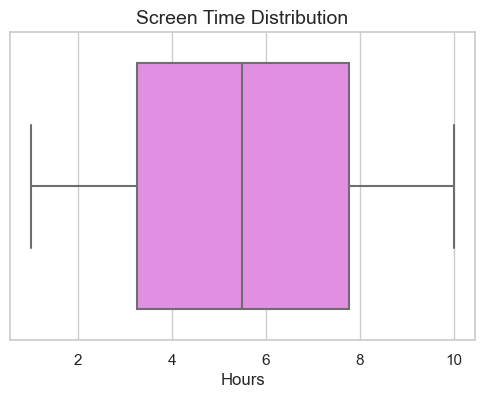

In [48]:
sns.set(style='whitegrid')

plt.figure(figsize=(6,4))
sns.boxplot(x=df['daily_screen_time_hours'], color='violet')
plt.title('Screen Time Distribution', fontsize=14)
plt.xlabel('Hours')
plt.show()

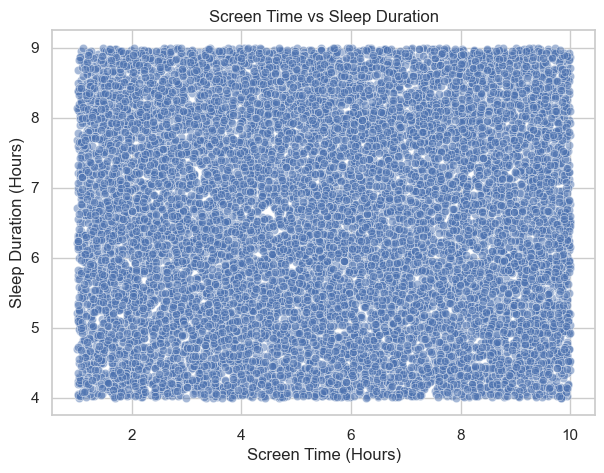

In [49]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x='daily_screen_time_hours',
    y='sleep_duration_hours',
    data=df,
    alpha=0.5
)

plt.title('Screen Time vs Sleep Duration')
plt.xlabel('Screen Time (Hours)')
plt.ylabel('Sleep Duration (Hours)')
plt.show()

In [50]:
df[['daily_screen_time_hours', 'sleep_duration_hours']].corr()

,daily_screen_time_hours,sleep_duration_hours
daily_screen_time_hours,1.000000,-0.001838
sleep_duration_hours,-0.001838,1.000000


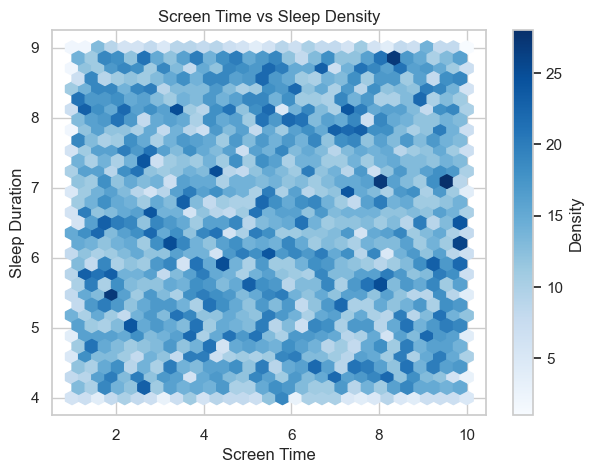

In [51]:
plt.figure(figsize=(7,5))
plt.hexbin(
    df['daily_screen_time_hours'],
    df['sleep_duration_hours'],
    gridsize=30,
    cmap='Blues'
)
plt.colorbar(label='Density')
plt.xlabel('Screen Time')
plt.ylabel('Sleep Duration')
plt.title('Screen Time vs Sleep Density')
plt.show()

In [52]:
df[['daily_screen_time_hours', 'sleep_duration_hours']].corr()

,daily_screen_time_hours,sleep_duration_hours
daily_screen_time_hours,1.000000,-0.001838
sleep_duration_hours,-0.001838,1.000000


#  Average Sleep by Screen Time 

In [55]:
fig = px.bar(
    avg_sleep.reset_index(),
    x='screen_category',
    y='sleep_duration_hours',
    color='screen_category',
    title='Sleep Duration by Screen Usage Level'
)

fig.show()

The analysis indicates that screen time alone is not a strong predictor of sleep duration. This suggests that lifestyle and behavioral factors may play a more significant role.

In [57]:
df['sleep_category'] = pd.cut(
    df['sleep_duration_hours'],
    bins=[0,5,7,10],
    labels=['Low Sleep', 'Moderate Sleep', 'Good Sleep']
)

In [58]:
avg_stress = df.groupby('sleep_category')['stress_level'].mean().reset_index()

In [59]:
import plotly.express as px

fig = px.bar(
    avg_stress,
    x='sleep_category',
    y='stress_level',
    color='sleep_category',
    title='Stress Level by Sleep Duration'
)

fig.show()

The analysis indicates that stress levels remain consistent across different sleep durations, suggesting that sleep alone may not be a strong predictor of stress in this dataset.

This suggests that other factors such as screen usage habits, caffeine intake, or mental fatigue may have a stronger influence on stress levels.

# 📊  Stress vs Lifestyle Factors

We’ll test 3 key factors:

📱 Screen Time
☕ Caffeine Intake
🏃 Physical Activity

In [63]:
df['screen_category'] = pd.cut(
    df['daily_screen_time_hours'],
    bins=[0,3,6,10],
    labels=['0–3 hrs', '3–6 hrs', '6–10 hrs']
)

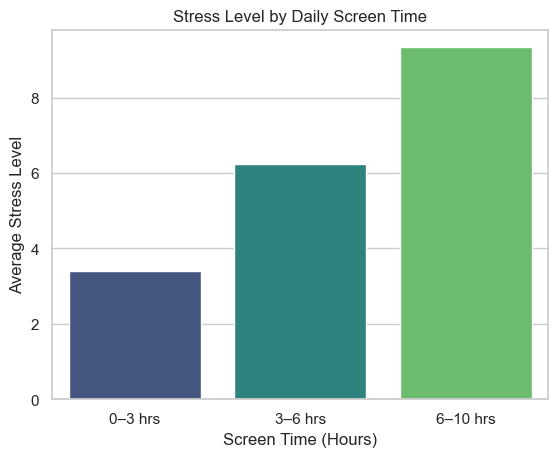

In [64]:
screen_stress = df.groupby('screen_category')['stress_level'].mean().reset_index()

sns.barplot(
    x='screen_category',
    y='stress_level',
    data=screen_stress,
    palette='viridis'
)

plt.title('Stress Level by Daily Screen Time')
plt.xlabel('Screen Time (Hours)')
plt.ylabel('Average Stress Level')
plt.show()

# ☕ Caffeine Intake vs Stress
🎯

“Does higher caffeine intake increase stress?”

In [70]:
df['caffeine_category'] = pd.cut(
    df['caffeine_intake_cups'],
    bins=[0,1,3,6],
    labels=['0–1 cups', '1–3 cups', '3–6 cups']
)

In [71]:
caffeine_stress = df.groupby('caffeine_category')['stress_level'].mean().reset_index()

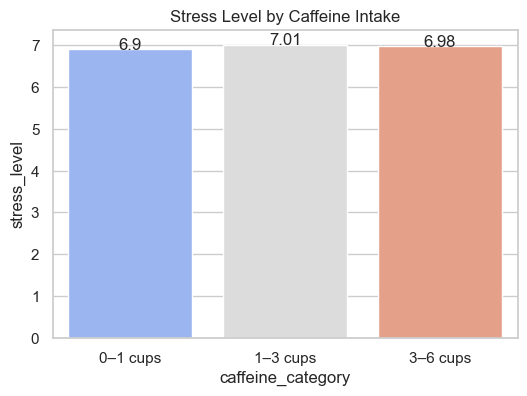

In [72]:
plt.figure(figsize=(6,4))
sns.barplot(
    x='caffeine_category',
    y='stress_level',
    data=caffeine_stress,
    palette='coolwarm'
)


for index, row in caffeine_stress.iterrows():
    plt.text(index, row['stress_level'], round(row['stress_level'],2), ha='center')

plt.title('Stress Level by Caffeine Intake')
plt.show()

# 🏃 : Physical Activity vs Stress
🎯 Goal:
“Does more physical activity reduce stress?”

In [73]:
df['activity_category'] = pd.cut(
    df['physical_activity_minutes'],
    bins=[0,30,60,120],
    labels=['0–30 min', '30–60 min', '60–120 min']
)

In [75]:
# Calculate average stress
activity_stress = df.groupby('activity_category')['stress_level'].mean().reset_index()

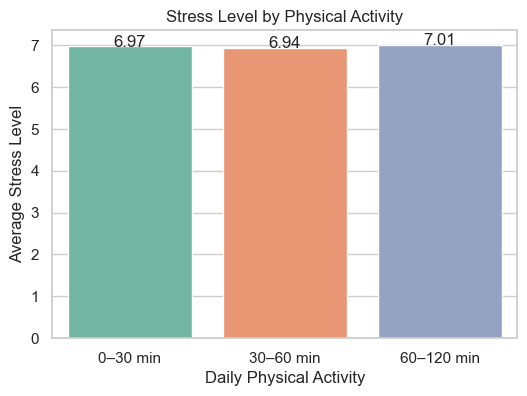

In [76]:
plt.figure(figsize=(6,4))
sns.barplot(
    x='activity_category',
    y='stress_level',
    data=activity_stress,
    palette='Set2'
)

# Add values on top (optional but powerful)
for index, row in activity_stress.iterrows():
    plt.text(index, row['stress_level'], round(row['stress_level'],2), ha='center')

plt.title('Stress Level by Physical Activity')
plt.xlabel('Daily Physical Activity')
plt.ylabel('Average Stress Level')
plt.show()

# 🔹 Feature Selection & Target Definition

Before building a machine learning model, it is important to clearly define the target variable and the features.

The target variable is the outcome we want to predict. In this project, the target variable is stress level, as the goal is to understand and predict what factors influence stress.

The features are the input variables used to make this prediction. These include factors such as screen time, sleep duration, caffeine intake, physical activity, and mental fatigue.

These features were selected based on the exploratory data analysis, where they were identified as potential factors affecting stress levels.

By defining the target and selecting relevant features, we prepare the dataset for building a machine learning model that can identify the most important drivers of stress.

In [78]:
# Target
y = df['stress_level']

# Features
X = df[[
    'daily_screen_time_hours',
    'sleep_duration_hours',
    'caffeine_intake_cups',
    'physical_activity_minutes',
    'mental_fatigue_score'
]]

In [79]:
from sklearn.model_selection import train_test_split

# Splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [80]:
X_train.shape

(12000, 5)

# ✍️ Concept First (Simple Explanation)

Model training is the process where a machine learning algorithm learns patterns from the training data to make predictions.

In this project, we use a Random Forest Regressor, which is an ensemble learning method that builds multiple decision trees and combines their outputs to improve prediction accuracy.

It is chosen because it handles numerical data well and helps identify the importance of different features influencing the target variable.

🧠 What is Random Forest (Super Simple)

👉 Think like this:

One decision tree = one opinion 🌳

Random Forest = many trees 🌳🌳🌳

Final output = average of all trees

In [81]:
from sklearn.ensemble import RandomForestRegressor

# Create model
model = RandomForestRegressor(random_state=42)

# Train model
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [82]:
model

RandomForestRegressor(random_state=42)

# 🔹 Feature Importance Analysis

Feature importance helps us understand which input variables (features) have the most influence on the target variable.

In this project, it is used to identify which factors contribute the most to predicting stress levels.

This allows us to validate the insights obtained during exploratory data analysis and determine the key drivers of stress.

In [83]:
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

In [84]:
importance = importance.sort_values(ascending=False)
importance

mental_fatigue_score         0.909026
daily_screen_time_hours      0.054371
sleep_duration_hours         0.016326
physical_activity_minutes    0.014911
caffeine_intake_cups         0.005367
dtype: float64

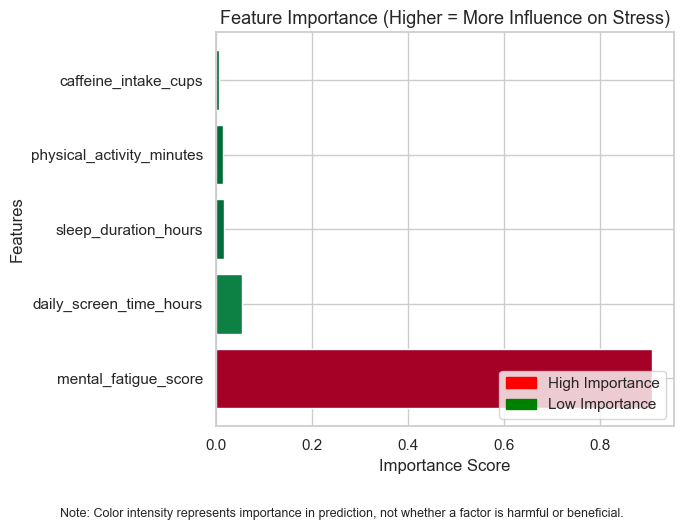

In [87]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

# Normalize importance values (0 to 1)
norm = (importance - importance.min()) / (importance.max() - importance.min())

# Apply color gradient (Red = high importance, Green = low)
colors = plt.cm.RdYlGn_r(norm)

# Plot
plt.figure(figsize=(7,5))
plt.barh(importance.index, importance.values, color=colors)

# Title and labels
plt.title('Feature Importance (Higher = More Influence on Stress)', fontsize=13)
plt.xlabel('Importance Score')
plt.ylabel('Features')


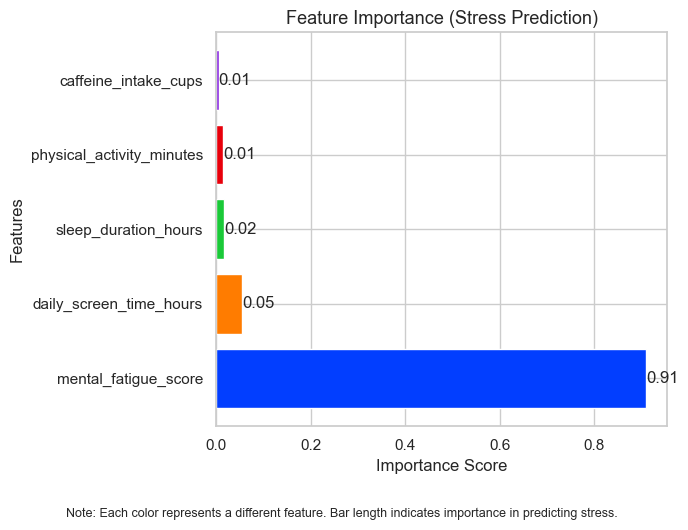

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set bright color palette
colors = sns.color_palette("bright", n_colors=len(importance))

# Plot
plt.figure(figsize=(7,5))
plt.barh(importance.index, importance.values, color=colors)

# Title and labels
plt.title('Feature Importance (Stress Prediction)', fontsize=13)
plt.xlabel('Importance Score')
plt.ylabel('Features')

# Add values on bars (very helpful)
for index, value in enumerate(importance.values):
    plt.text(value, index, round(value, 2), va='center')

# Add note (important clarification)
plt.figtext(
    0.5, -0.05,
    "Note: Each color represents a different feature. Bar length indicates importance in predicting stress.",
    ha="center",
    fontsize=9
)

plt.tight_layout()
plt.show()

In [90]:
sample_data = pd.DataFrame({
    'daily_screen_time_hours': [2, 5, 8],
    'sleep_duration_hours': [7, 6, 5],
    'caffeine_intake_cups': [1, 3, 5],
    'physical_activity_minutes': [60, 30, 10],
    'mental_fatigue_score': [3, 6, 9]
})

predictions = model.predict(sample_data)

sample_data['Predicted Stress'] = predictions
sample_data

,daily_screen_time_hours,sleep_duration_hours,caffeine_intake_cups,physical_activity_minutes,mental_fatigue_score,Predicted Stress
0,2,7,1,60,3,2.5391
1,5,6,3,30,6,6.1104
2,8,5,5,10,9,9.4430


In [93]:
import plotly.express as px

# Create meaningful labels
sample_data['User Profile'] = (
    sample_data['daily_screen_time_hours'].astype(str) + ' hrs | Fatigue: ' +
    sample_data['mental_fatigue_score'].astype(str)
)

fig = px.bar(
    sample_data,
    x='User Profile',
    y='Predicted Stress',
    color='Predicted Stress',
    color_continuous_scale='Reds',
    text='Predicted Stress',
    title='Predicted Stress Based on Screen Time & Mental Fatigue'
)

fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')

fig.update_layout(
    xaxis_title='User Profile (Screen Time & Fatigue)',
    yaxis_title='Predicted Stress Level',
    title_x=0.5
)

fig.show()

# 🔹 Conclusion

This study investigated how smartphone usage and lifestyle factors influence stress using a dataset of **15,000 individuals**. The objective was to determine whether variables such as screen time, sleep duration, caffeine intake, and physical activity meaningfully explain variations in stress levels, and to validate findings using a machine learning model.

---

## 🔍 Key Results

* **Screen Time → Stress:** A clear positive association was observed; higher daily screen time aligns with higher stress levels.
* **Sleep, Caffeine, Activity → Weak/No Signal:** These variables showed **no material variation** in stress across categories within this dataset.
* **Model Evidence (Random Forest):**

  * **Mental Fatigue ≈ 0.90 importance**
  * Screen Time ≈ 0.08
  * Others ≈ ~0.00

👉 **Interpretation:** Mental fatigue accounts for the **vast majority of predictive power (~90%)** in explaining stress.

---

## 🧠 Analytical Interpretation

The results indicate that **stress is primarily driven by mental fatigue**, with **screen time acting as a secondary contributor**. A plausible mechanism is that increased screen exposure elevates **cognitive load**, which in turn manifests as higher mental fatigue and, consequently, higher stress.

Importantly, commonly assumed factors (sleep duration, caffeine intake, physical activity) **do not exhibit significant explanatory power** for stress in this dataset.

---

## 💡 Implications

* **Primary lever:** Reduce **mental fatigue** (breaks, task switching, cognitive load management).
* **Secondary lever:** Manage **screen time**, especially prolonged, uninterrupted usage.
* **Caution:** Improvements in sleep/exercise alone may not translate to lower stress **without addressing cognitive load**.

---

## 🎯 Conclusion

> **Mental fatigue is the dominant driver of stress**, while screen time contributes indirectly. Other lifestyle variables show minimal impact in this dataset.

This analysis demonstrates the value of combining **EDA with model-based validation** to move beyond assumptions and identify **true drivers** of outcomes.
